<center>
    
## Investigacion II: Simulación Electromagnetica Cubos
### Todos los prototipos
**Camila Uribe - 202217043**
</center>

#### Codigo general

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy
from matplotlib.patches import Rectangle, Circle
from matplotlib.colors import LogNorm
import ezdxf
from ezdxf import path as ezpath
import logging
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm, Normalize
logging.getLogger("ezdxf").setLevel(logging.ERROR)

In [3]:
# ---------- Plot style ----------
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

QUIVER_STEP = 10
QUIVER_WIDTH = 0.0025
PATCH_LW = 1.2

def bbox_limits_mm(polys_m, pad_mm=2.0):
    """Return (x_lim_mm, y_lim_mm) that contains all polylines + padding."""
    allpts = np.vstack(polys_m)
    xmax = np.max(np.abs(allpts[:,0])) * 1e3
    ymax = np.max(np.abs(allpts[:,1])) * 1e3
    return float(xmax + pad_mm), float(ymax + pad_mm)

In [4]:
class ForceLog:
    def __init__(self):
        self.rows = []

    def add(self, stage, label, I_A, F_vec_N):
        Fx, Fy, Fz = float(F_vec_N[0]), float(F_vec_N[1]), float(F_vec_N[2])
        self.rows.append({
            "stage": stage,
            "label": label,
            "I_A": float(I_A),
            "Fx_N": Fx,
            "Fy_N": Fy,
            "Fz_N": Fz,
            "Fmag_N": float(np.linalg.norm([Fx, Fy, Fz])),
        })

    def df(self):
        return pd.DataFrame(self.rows)

    def plot_components(self, title="Forces (Fx,Fy,Fz)"):
        df = self.df()
        if df.empty:
            print("ForceLog is empty.")
            return

        x = np.arange(len(df))
        w = 0.25

        plt.figure(figsize=(max(7, 0.55*len(df)), 3.8), dpi=150)
        plt.bar(x - w, df["Fx_N"].values, width=w, label="Fx")
        plt.bar(x,      df["Fy_N"].values, width=w, label="Fy")
        plt.bar(x + w, df["Fz_N"].values, width=w, label="Fz")
        plt.axhline(0, linewidth=0.8)
        plt.xticks(x, [f'{s}:{l}' for s,l in zip(df["stage"], df["label"])], rotation=45, ha="right")
        plt.ylabel("Force (N)")
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()

<center>

### Funciones para todos los calculos/graficas

In [5]:
# ---------- GLOBAL STORAGE FOR PROTOTYPE FORCES----------
prototype_force_results = {}

def quiver_unit(ax, Xmm, Ymm, U, V, step=10, width=0.0025, alpha=0.85):
    eps = 1e-12
    Xs = Xmm[::step, ::step]
    Ys = Ymm[::step, ::step]
    Us = U[::step, ::step]
    Vs = V[::step, ::step]
    M = np.sqrt(Us**2 + Vs**2) + eps
    Us = Us / M
    Vs = Vs / M
    ax.quiver(Xs, Ys, Us, Vs, color="white", scale=30, width=width, alpha=alpha)

def poly_length(poly_xy):
    d = np.diff(poly_xy, axis=0)
    return float(np.sum(np.sqrt(np.sum(d*d, axis=1))))

def bbox_limits_mm(polys_m, pad_mm=2.0):
    allpts = np.vstack(polys_m)
    xmax = np.max(np.abs(allpts[:, 0])) * 1e3
    ymax = np.max(np.abs(allpts[:, 1])) * 1e3
    return float(xmax + pad_mm), float(ymax + pad_mm)

# ---------- Magnet builders ----------
def build_cuboid_collection(cub_specs):
    mags = []
    for s in cub_specs:
        m = magpy.magnet.Cuboid(
            dimension=s["dim"],
            polarization=s["pol"]
        )
        m.position = s["pos"]
        mags.append(m)
    return magpy.Collection(*mags), mags

# ---------- Field plots ----------
def plot_Bz_line(src, x0=0.0, y0=0.0, zmin=1e-3, zmax=50e-3, n=300, title="Bz vs z", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=120)

    z = np.linspace(zmin, zmax, n)
    pts = np.c_[np.full_like(z, x0), np.full_like(z, y0), z]
    B = src.getB(pts)
    Bz = B[:, 2]

    ax.plot(z * 1e3, Bz * 1e3)
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("Bz (mT)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_XZ_map_cuboids(src, cub_specs=None,
                        x_lim_mm=40, z_min_mm=-30, z_max_mm=30, nx=241, nz=241,
                        y_slice=0.0, title="XZ slice: |B|", ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=120)

    xg = np.linspace(-x_lim_mm, x_lim_mm, nx) * 1e-3
    zg = np.linspace(z_min_mm, z_max_mm, nz) * 1e-3
    X, Z = np.meshgrid(xg, zg)
    Y = np.full_like(X, y_slice)

    pts = np.c_[X.ravel(), Y.ravel(), Z.ravel()]
    B = src.getB(pts).reshape(Z.shape + (3,))
    Bx, Bz = B[..., 0], B[..., 2]
    Bmag_mT = np.linalg.norm(B, axis=2) * 1e3

    vmax = max(np.max(Bmag_mT), 1.01)

    im = ax.imshow(
        Bmag_mT,
        extent=[xg.min()*1e3, xg.max()*1e3, zg.min()*1e3, zg.max()*1e3],
        origin="lower",
        aspect="equal",
        norm=LogNorm(vmin=1.0, vmax=vmax)
    )
    ax.figure.colorbar(im, ax=ax, label="|B| (mT)")
    ax.set_title(title)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("z (mm)")

    quiver_unit(ax, X*1e3, Z*1e3, Bx, Bz, step=QUIVER_STEP, width=QUIVER_WIDTH)

    if cub_specs is not None:
        for s in cub_specs:
            dx, dy, dz = s["dim"]
            xm, ym, zm = s["pos"]

            ax.add_patch(Rectangle(
                ((xm - dx/2) * 1e3, (zm - dz/2) * 1e3),
                dx * 1e3,
                dz * 1e3,
                fill=False,
                edgecolor="black",
                linewidth=PATCH_LW
            ))

    ax.set_xlim(-x_lim_mm, x_lim_mm)
    ax.set_ylim(z_min_mm, z_max_mm)

def plot_XY_map_cuboids(src, z_plane,
                        cub_specs=None, overlay_polys_m=None,
                        x_lim_mm=50, y_lim_mm=40, nx=241, ny=241,
                        title="XY slice: |B|", ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=120)

    xg = np.linspace(-x_lim_mm, x_lim_mm, nx) * 1e-3
    yg = np.linspace(-y_lim_mm, y_lim_mm, ny) * 1e-3
    X, Y = np.meshgrid(xg, yg)
    Z = np.full_like(X, z_plane)

    pts = np.c_[X.ravel(), Y.ravel(), Z.ravel()]
    B = src.getB(pts).reshape(Y.shape + (3,))
    Bx, By = B[..., 0], B[..., 1]
    Bmag_mT = np.linalg.norm(B, axis=2) * 1e3

    vmax = max(np.max(Bmag_mT), 1.01)

    im = ax.imshow(
        Bmag_mT,
        extent=[xg.min()*1e3, xg.max()*1e3, yg.min()*1e3, yg.max()*1e3],
        origin="lower",
        aspect="equal",
        norm=LogNorm(vmin=1.0, vmax=vmax)
    )
    ax.figure.colorbar(im, ax=ax, label="|B| (mT)")
    ax.set_title(title + f"  (z={z_plane*1e3:.2f} mm)")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

    quiver_unit(ax, X*1e3, Y*1e3, Bx, By, step=QUIVER_STEP, width=QUIVER_WIDTH)

    if cub_specs is not None:
        for s in cub_specs:
            dx, dy, dz = s["dim"]
            xm, ym, zm = s["pos"]

            ax.add_patch(Rectangle(
                ((xm - dx/2) * 1e3, (ym - dy/2) * 1e3),
                dx * 1e3,
                dy * 1e3,
                fill=False,
                edgecolor="black",
                linewidth=PATCH_LW
            ))

    if overlay_polys_m is not None:
        for i, poly in enumerate(overlay_polys_m):
            ax.plot(poly[:, 0]*1e3, poly[:, 1]*1e3, linewidth=1.1, label=f"coil #{i+1}")
        ax.legend(loc="upper left", framealpha=0.7)

    ax.set_xlim(-x_lim_mm, x_lim_mm)
    ax.set_ylim(-y_lim_mm, y_lim_mm)

# ---------- Force on polyline ----------
def force_on_polyline(I, pts_xy_m, z_coil_m, B_func):
    pts3 = np.column_stack([
        pts_xy_m[:, 0],
        pts_xy_m[:, 1],
        np.full(len(pts_xy_m), z_coil_m)
    ])

    dl = pts3[1:] - pts3[:-1]
    mid = 0.5 * (pts3[1:] + pts3[:-1])
    B = B_func(mid)
    dF = I * np.cross(dl, B)

    return np.sum(dF, axis=0)

def read_dxf_paths(filepath, flatten_tol=0.1, ignore_types=("TEXT","MTEXT","DIMENSION","HATCH")):
    doc = ezdxf.readfile(filepath)
    msp = doc.modelspace()
    polylines = []
    for e in msp:
        if e.dxftype() in ignore_types:
            continue
        try:
            p = ezpath.make_path(e)
        except Exception:
            continue
        pts = [(v.x, v.y) for v in p.flattening(distance=flatten_tol)]
        if len(pts) >= 2:
            polylines.append(np.array(pts, dtype=float))
    return polylines

def pick_paths(polys_units, pick="all", k=1):
    if pick == "all":
        return polys_units
    if pick == "longest":
        L = np.array([poly_length(p) for p in polys_units], dtype=float)
        idx = np.argsort(-L)[:k]
        return [polys_units[i] for i in idx]
    raise ValueError("pick must be 'all' or 'longest'")

def place_paths(polys_units, units_to_m=1e-3,
                center_mode="global",
                target_center_m=(0.0, 0.0),
                rotate_deg=0.0,
                scale=1.0):

    polys = [p.copy() for p in polys_units]

    if center_mode == "global" and len(polys) > 0:
        allpts = np.vstack(polys)
        c = allpts.mean(axis=0)
        polys = [p - c for p in polys]

    polys_m = [p * (units_to_m * scale) for p in polys]

    th = np.deg2rad(rotate_deg)
    R = np.array([
        [np.cos(th), -np.sin(th)],
        [np.sin(th),  np.cos(th)]
    ], dtype=float)
    polys_m = [p @ R.T for p in polys_m]

    tx, ty = target_center_m
    polys_m = [p + np.array([tx, ty]) for p in polys_m]

    return polys_m

def xy_map_dxf_forces_cuboids(src, dxf_path, z_plane,
                              currents,
                              cub_specs=None,
                              x_lim_mm=30, y_lim_mm=30, n=241,
                              auto_fit_dxf=True, pad_mm=2.0,
                              flatten_tol=0.1, units_to_m=1e-3,
                              pick="longest", k=1,
                              center_mode="global",
                              target_center_m=(0.0, 0.0),
                              rotate_deg=90.0,
                              scale=1.0,
                              title="XY |B| + DXF + Forces",
                              ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=120)

    polys_units = read_dxf_paths(dxf_path, flatten_tol=flatten_tol)
    if len(polys_units) == 0:
        raise ValueError("DXF parsing returned 0 usable paths.")

    polys_units = pick_paths(polys_units, pick=pick, k=k)
    polys_m = place_paths(
        polys_units,
        units_to_m=units_to_m,
        center_mode=center_mode,
        target_center_m=target_center_m,
        rotate_deg=rotate_deg,
        scale=scale
    )

    if isinstance(currents, (int, float)):
        currents = [float(currents)]
    if len(currents) != len(polys_m):
        raise ValueError(f"currents length ({len(currents)}) must match selected paths ({len(polys_m)}).")

    if auto_fit_dxf:
        x_lim_mm, y_lim_mm = bbox_limits_mm(polys_m, pad_mm=pad_mm)

    plot_XY_map_cuboids(
        src=src,
        z_plane=z_plane,
        cub_specs=cub_specs,
        overlay_polys_m=polys_m,
        x_lim_mm=x_lim_mm,
        y_lim_mm=y_lim_mm,
        nx=n,
        ny=n,
        title=title,
        ax=ax
    )

    forces = []
    for I, poly in zip(currents, polys_m):
        forces.append(force_on_polyline(I, poly, z_plane, src.getB))
    F_total = np.sum(forces, axis=0)

    print("\nForces (N):")
    for i, F in enumerate(forces):
        print(f"  coil #{i+1}, I={currents[i]:.6g} A -> F = {F}")
    print("  TOTAL -> F_total =", F_total)

    return polys_m, forces, F_total, (x_lim_mm, y_lim_mm)

def plot_dxf_segment_force_map_cuboids(polys_m, currents, z_plane, B_func,
                                       cub_specs=None,
                                       x_lim_mm=50, y_lim_mm=40,
                                       component="z",
                                       sensitivity_pct=90,
                                       title="DXF segment force map",
                                       ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

    ax.set_facecolor("#111111")

    if isinstance(currents, (int, float)):
        currents = [float(currents)]

    if len(currents) != len(polys_m):
        raise ValueError(f"currents length ({len(currents)}) must match number of polylines ({len(polys_m)}).")

    all_segments_mm = []
    all_values = []

    for I, poly in zip(currents, polys_m):
        if len(poly) < 2:
            continue

        pts3 = np.column_stack([
            poly[:, 0],
            poly[:, 1],
            np.full(len(poly), z_plane)
        ])

        dl = pts3[1:] - pts3[:-1]
        mid = 0.5 * (pts3[1:] + pts3[:-1])
        B = B_func(mid)
        dF = I * np.cross(dl, B)

        if component == "x":
            vals = dF[:, 0]
            cbar_label = "dFx (N)"
            cmap = "seismic"
        elif component == "y":
            vals = dF[:, 1]
            cbar_label = "dFy (N)"
            cmap = "seismic"
        elif component == "z":
            vals = dF[:, 2]
            cbar_label = "dFz (N)"
            cmap = "seismic"
        elif component == "mag":
            vals = np.linalg.norm(dF, axis=1)
            cbar_label = "|dF| (N)"
            cmap = "plasma"
        else:
            raise ValueError("component must be 'x', 'y', 'z', or 'mag'")

        segs_mm = np.stack([poly[:-1] * 1e3, poly[1:] * 1e3], axis=1)

        all_segments_mm.append(segs_mm)
        all_values.append(vals)

    segments_mm = np.concatenate(all_segments_mm, axis=0)
    values = np.concatenate(all_values, axis=0)

    if component == "mag":
        vmax = np.percentile(values, sensitivity_pct)
        vmax = max(vmax, 1e-18)
        norm = Normalize(vmin=0.0, vmax=vmax)
    else:
        vmax = np.percentile(np.abs(values), sensitivity_pct)
        vmax = max(vmax, 1e-18)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    lc = LineCollection(
        segments_mm,
        cmap=cmap,
        norm=norm,
        linewidths=2.0,
        capstyle="round"
    )
    lc.set_array(values)
    ax.add_collection(lc)

    cbar = ax.figure.colorbar(lc, ax=ax)
    cbar.set_label(cbar_label)

    if cub_specs is not None:
        for s in cub_specs:
            dx, dy, dz = s["dim"]
            xm, ym, zm = s["pos"]

            ax.add_patch(Rectangle(
                ((xm - dx/2) * 1e3, (ym - dy/2) * 1e3),
                dx * 1e3,
                dy * 1e3,
                fill=False,
                edgecolor="white",
                linewidth=1.4
            ))

    ax.set_title(title + f"  (z={z_plane*1e3:.2f} mm)")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_xlim(-x_lim_mm, x_lim_mm)
    ax.set_ylim(-y_lim_mm, y_lim_mm)
    ax.set_aspect("equal")

# ---------- Prototype runner ----------
def run_prototype_cuboids(prot):
    name = prot.get("name", "prototype")

    src, _ = build_cuboid_collection(prot["cub_magnets"])

    fig, axs = plt.subplots(3, 2, figsize=(14, 12), dpi=140, constrained_layout=True)

    ax_bz = axs[0, 0]
    ax_xz = axs[0, 1]
    ax_xy = axs[1, 0]
    ax_xy_dxf = axs[1, 1]
    ax_force = axs[2, 0]
    ax_blank = axs[2, 1]

    # Bz line
    bz = prot.get("bz_line", {})
    plot_Bz_line(
        src,
        **{k: v for k, v in bz.items() if k != "title"},
        title=f"{name} — {bz.get('title', 'Bz line')}",
        ax=ax_bz
    )

    # XZ map
    xz = prot.get("xz_map", {})
    plot_XZ_map_cuboids(
        src,
        cub_specs=prot["cub_magnets"],
        **{k: v for k, v in xz.items() if k != "title"},
        title=f"{name} — {xz.get('title', 'XZ |B|')}",
        ax=ax_xz
    )

    # XY map
    xy = prot.get("xy_map", {})
    z_plane = xy["z_plane"]

    plot_XY_map_cuboids(
        src,
        z_plane,
        cub_specs=prot["cub_magnets"],
        x_lim_mm=xy.get("x_lim_mm", 30),
        y_lim_mm=xy.get("y_lim_mm", 30),
        nx=xy.get("n", 241),
        ny=xy.get("n", 241),
        title=f"{name} — XY |B|",
        ax=ax_xy
    )

    # DXF + forces
    dxf = prot.get("dxf", None)

    if dxf and dxf.get("dxf_path", None):
        polys_m, forces, F_total, _ = xy_map_dxf_forces_cuboids(
            src=src,
            dxf_path=dxf["dxf_path"],
            z_plane=dxf.get("z_plane", z_plane),
            currents=dxf["currents"],
            cub_specs=prot["cub_magnets"],
            x_lim_mm=dxf.get("x_lim_mm", xy.get("x_lim_mm", 30)),
            y_lim_mm=dxf.get("y_lim_mm", xy.get("y_lim_mm", 30)),
            n=dxf.get("n", xy.get("n", 241)),
            auto_fit_dxf=dxf.get("auto_fit_dxf", True),
            pad_mm=dxf.get("pad_mm", 2.0),
            flatten_tol=dxf.get("flatten_tol", 0.1),
            units_to_m=dxf.get("units_to_m", 1e-3),
            pick=dxf.get("pick", "longest"),
            k=dxf.get("k", 1),
            center_mode=dxf.get("center_mode", "global"),
            target_center_m=dxf.get("target_center_m", (0.0, 0.0)),
            rotate_deg=dxf.get("rotate_deg", 0.0),
            scale=dxf.get("scale", 1.0),
            title=f"{name} — XY |B| + DXF + Forces",
            ax=ax_xy_dxf
        )

        prototype_force_results[name] = {
            "Fx_N": float(F_total[0]),
            "Fy_N": float(F_total[1]),
            "Fz_N": float(F_total[2]),
            "Fmag_N": float(np.linalg.norm(F_total)),
        }

        force_cfg = prot.get("force_map", {})

        plot_dxf_segment_force_map_cuboids(
            polys_m=polys_m,
            currents=dxf["currents"],
            z_plane=dxf.get("z_plane", z_plane),
            B_func=src.getB,
            cub_specs=prot["cub_magnets"],
            x_lim_mm=force_cfg.get("x_lim_mm", dxf.get("x_lim_mm", xy.get("x_lim_mm", 30))),
            y_lim_mm=force_cfg.get("y_lim_mm", dxf.get("y_lim_mm", xy.get("y_lim_mm", 30))),
            component=force_cfg.get("component", "z"),
            sensitivity_pct=force_cfg.get("sensitivity_pct", 90),
            title=f"{name} — DXF segment force map",
            ax=ax_force
        )
    else:
        ax_xy_dxf.set_visible(False)
        ax_force.set_visible(False)

    ax_blank.axis("off")

    plt.show()
    return src

<center>

### Prototipos

#### Prototipo 6: Rectas Paralelas


Forces (N):
  coil #1, I=0.35 A -> F = [0.00000000e+00 0.00000000e+00 9.21037637e-05]
  coil #2, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -5.90294215e-07]
  coil #3, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -9.24382725e-05]
  coil #4, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -5.84458377e-07]
  coil #5, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -5.54305347e-07]
  coil #6, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -5.00418009e-07]
  coil #7, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -4.25447546e-07]
  coil #8, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -3.33414286e-07]
  coil #9, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -2.28891455e-07]
  coil #10, I=0.35 A -> F = [ 0.00000000e+00  0.00000000e+00 -1.16373741e-07]
  coil #11, I=0.35 A -> F = [0. 0. 0.]
  coil #12, I=0.35 A -> F = [0.00000000e+00 0.00000000e+00 1.16373741e-07]
  coil #13, I=0.35 A -> F = [0.00000000e+00 0.00000000e+00 2.28891455e-07]
  coil #14, I=0.35 A -> F = [0

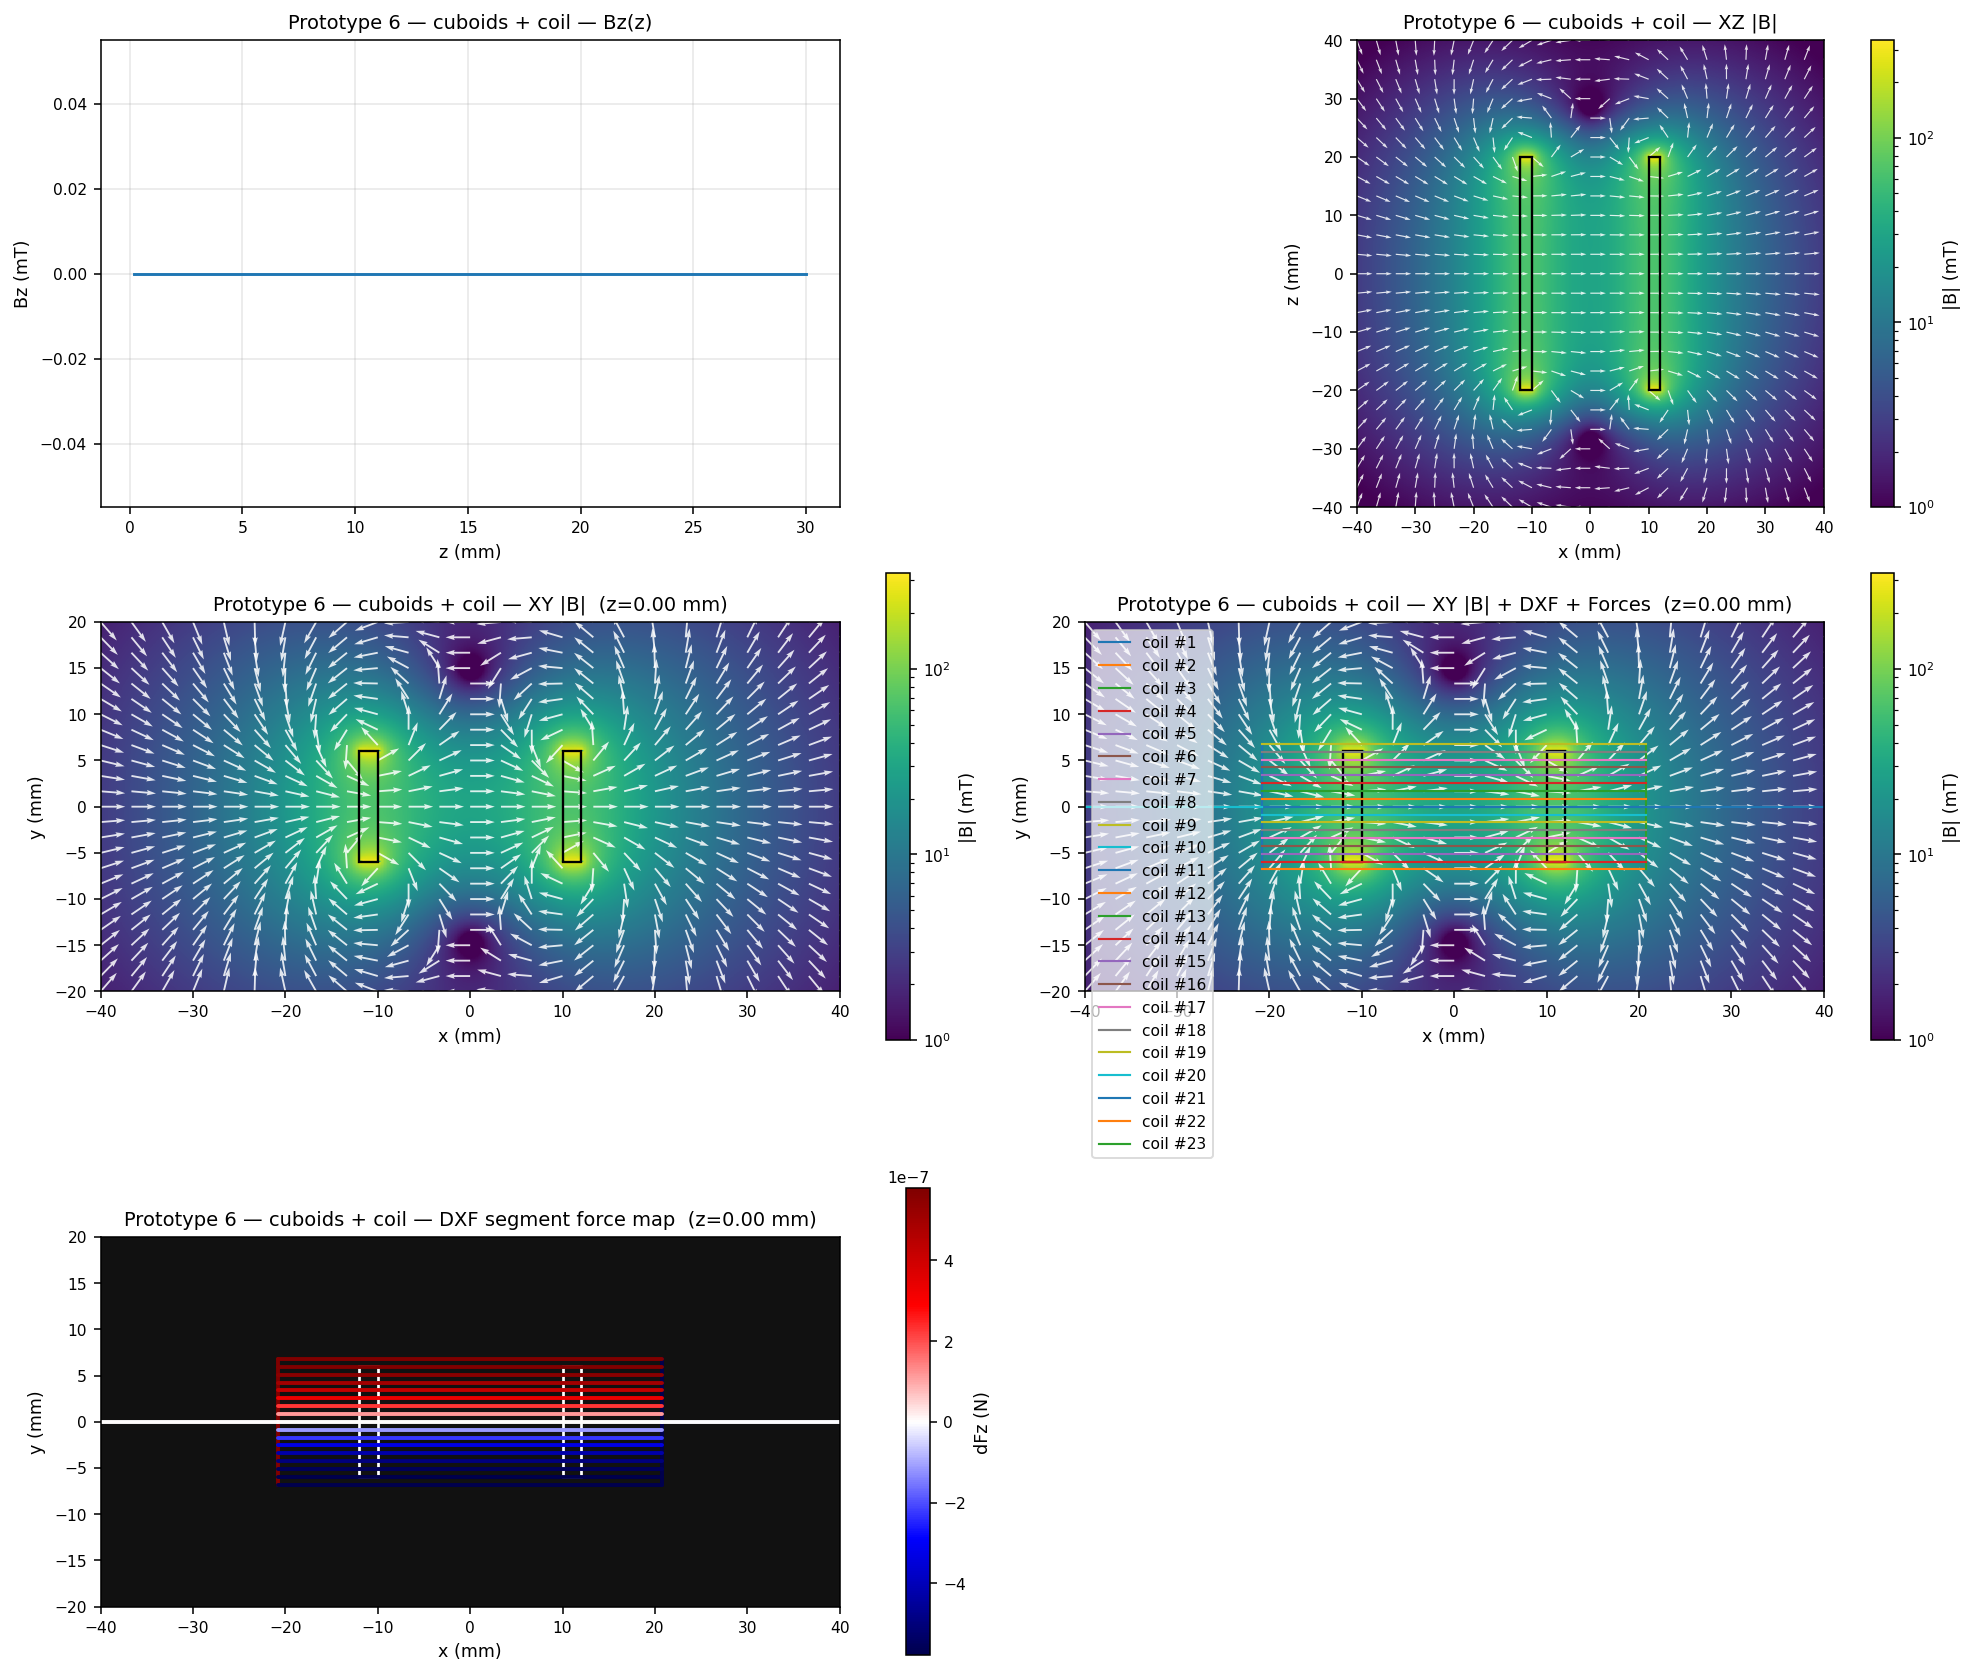

In [8]:
# =========================
# Prototype 6 — cuboids + coil
# =========================

# --- Magnet parameters ---
J = 0.55   # Tesla
gap = 20e-3

# Cuboid dimensions: (dx, dy, dz)
dim_x = 2e-3
dim_y = 12e-3
dim_z = 40e-3

# Magnet center positions
x0 = 0.5 * (gap + dim_x)   # 11 mm

# --- Coil / DXF ---
dxf_path = "/Users/camilauribequintero/Desktop/tesis/grill_circuit_semana4.dxf"
I0 = 0.35   # A

prototype6 = {
    "name": "Prototype 6 — cuboids + coil",

    "cub_magnets": [
        {"dim": (dim_x, dim_y, dim_z), "pos": (-x0, 0.0, 0.0), "pol": (+J, 0.0, 0.0)},
        {"dim": (dim_x, dim_y, dim_z), "pos": (+x0, 0.0, 0.0), "pol": (+J, 0.0, 0.0)},
    ],

    # 1D line sample
    "bz_line": {
        "x0": 0.0,
        "y0": 0.0,
        "zmin": 0.2e-3,
        "zmax": 30e-3,
        "n": 300,
        "title": "Bz(z)"
    },

    # XZ slice
    "xz_map": {
        "x_lim_mm": 40,
        "z_min_mm": -40,
        "z_max_mm": 40,
        "nx": 241,
        "nz": 241,
        "y_slice": 0.0,
        "title": "XZ |B|"
    },

    # XY slice
    "xy_map": {
        "z_plane": 0.0,
        "x_lim_mm": 40,
        "y_lim_mm": 20,
        "n": 241
    },

    # DXF overlay + total force
    "dxf": {
        "dxf_path": dxf_path,
        "currents": [I0]*23,
        "z_plane": 0.0,
        "pick": "all",
        "k": 1,
        "flatten_tol": 0.05,
        "units_to_m": 1e-3,
        "target_center_m": (0.0, 0.0),
        "rotate_deg": 0.0,
        "scale": 1.0,
        "x_lim_mm": 40,
        "y_lim_mm": 20,
        "n": 241,
        "auto_fit_dxf": False
    },

    # Segment-force map
    "force_map": {
        "x_lim_mm": 40,
        "y_lim_mm": 20,
        "component": "z",
        "sensitivity_pct": 90
    }
}

# Run
src6 = run_prototype_cuboids(prototype6)